**eda: movie profitability.** this looks at the 4,381 films that have a real budget and revenue and a budget of at least $4M (2017 dollars) (see `src/prepare.py` for how they got picked), and for runtime and ratings also compares them to every released film from 1970 on. money is in 2017 dollars. ratings are tmdb `vote_average`, only counted when a film has at least 50 votes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter

BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#a3a29c"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})


def money(x, _=None):
    for size, unit in [(1e9, "B"), (1e6, "M"), (1e3, "k")]:
        if abs(x) >= size:
            return f"${x / size:g}{unit}"
    return f"${x:g}"


MONEY = FuncFormatter(money)
PCT = PercentFormatter(1.0, decimals=0)
RATING_RANGE = (5.5, 7.0)  # same scale on every rating chart so small gaps don't look huge


def save(fig, name):
    fig.savefig(f"../figures/{name}.png")


def dots(ax, labels, series, title):
    # horizontal dot plot. series is a list of (values, color, name)
    y = np.arange(len(labels))
    for values, color, name in series:
        ax.scatter(values, y, color=color, s=34, label=name, zorder=3)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)


def legend_below(ax):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2, fontsize=8.5)

In [2]:
MIN_VOTES = 50

d = pd.read_csv("../data/processed/movies_clean.csv")
d["rating"] = d["vote_average"].where(d["vote_count"] >= MIN_VOTES)

# every released film from 1970 on, whether or not it has money data. only used to compare samples
allm = pd.read_csv("../data/raw/movies_metadata.csv", low_memory=False)
allm["id"] = pd.to_numeric(allm["id"], errors="coerce")
allm = allm.dropna(subset=["id"]).drop_duplicates("id")
allm["year"] = pd.to_datetime(allm["release_date"], errors="coerce").dt.year
allm = allm[(allm["status"] == "Released") & (allm["year"] >= 1970)].copy()
allm = allm[allm["runtime"].between(40, 300)]  # same runtime rule as the money sample
allm["rating"] = allm["vote_average"].where(allm["vote_count"] >= MIN_VOTES)

print(f"money sample: {len(d):,} films, {d.rating.notna().mean():.1%} have 50+ votes")
print(f"all released since 1970: {len(allm):,} films, {allm.rating.notna().mean():.1%} have 50+ votes")

money sample: 4,381 films, 87.9% have 50+ votes
all released since 1970: 34,145 films, 24.5% have 50+ votes


**0. which films are in.**

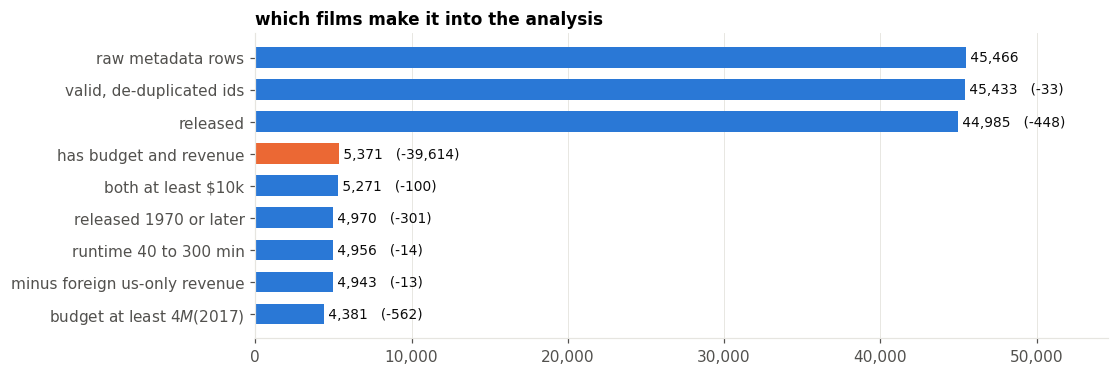

In [3]:
raw = pd.read_csv("../data/raw/movies_metadata.csv", low_memory=False)
raw["id"] = pd.to_numeric(raw["id"], errors="coerce")
raw["budget"] = pd.to_numeric(raw["budget"], errors="coerce")
raw["year"] = pd.to_datetime(raw["release_date"], errors="coerce").dt.year

# same rules as src/prepare.py, one step at a time
f = raw
steps = [("raw metadata rows", len(f))]
f = f.dropna(subset=["id"]).drop_duplicates("id")
steps.append(("valid, de-duplicated ids", len(f)))
f = f[f["status"] == "Released"]
steps.append(("released", len(f)))
f = f[(f["budget"] > 0) & (f["revenue"] > 0)]
steps.append(("has budget and revenue", len(f)))
f = f[(f["budget"] >= 10_000) & (f["revenue"] >= 10_000)]
steps.append(("both at least $10k", len(f)))
f = f[f["year"] >= 1970]
steps.append(("released 1970 or later", len(f)))
f = f[f["runtime"].between(40, 300)]
steps.append(("runtime 40 to 300 min", len(f)))
f = f[~((f["original_language"] != "en") & (f["revenue"] < 0.01 * f["budget"]))]
steps.append(("minus foreign films with only US revenue", len(f)))
cpi = pd.read_csv("../data/cpi_raw.csv", parse_dates=["observation_date"])
cpi = cpi.groupby(cpi["observation_date"].dt.year)["CPIAUCNS"].mean()
f = f[f["budget"] * f["year"].map(cpi[2017] / cpi) >= 4e6]
steps.append(("budget at least $4M in 2017 dollars", len(f)))

names = [name for name, _ in steps]
counts = [n for _, n in steps]
dropped = [0] + [a - b for a, b in zip(counts, counts[1:])]
biggest = int(np.argmax(dropped))

fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(steps))
colors = [ORANGE if i == biggest else BLUE for i in y]
ax.barh(y, counts, color=colors, height=0.65)
for i, (n, cut) in enumerate(zip(counts, dropped)):
    label = f" {n:,}" + (f"   (-{cut:,})" if cut else "")
    ax.text(n, i, label, va="center", color=INK, fontsize=9)
ax.set_yticks(y, names)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, counts[0] * 1.2)
ax.grid(axis="y", visible=False)
ax.set_title("which films make it into the analysis")
save(fig, "00_funnel")

assert counts[-1] == len(d), "funnel doesn't match the clean data"

**1. distributions.**

      budget_real revenue_real
count     $4.381k      $4.381k
mean    $49.1052M     $146.18M
std     $48.8262M    $232.912M
min           $4M    $12.9142k
10%     $7.90349M    $4.83858M
50%     $32.3966M      $64.08M
90%      $113.76M    $380.178M
max     $414.092M    $3.18539B


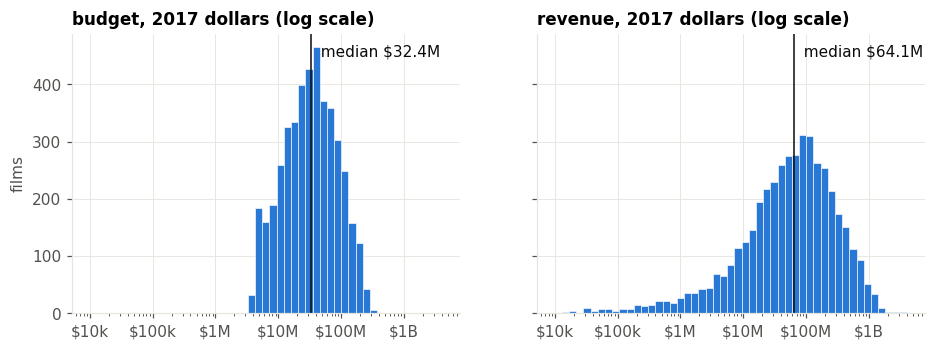

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3), sharey=True)
bins = np.logspace(4, 9.6, 50)
for ax, col, name in [(axes[0], "budget_real", "budget"), (axes[1], "revenue_real", "revenue")]:
    ax.hist(d[col], bins=bins, color=BLUE, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(MONEY)
    median = d[col].median()
    ax.axvline(median, color=INK, linewidth=1)
    ax.text(median, ax.get_ylim()[1] * 0.92, f"  median {money(round(median, -5))}", color=INK)
    ax.set_title(f"{name}, 2017 dollars (log scale)")
axes[0].set_ylabel("films")
save(fig, "01_budget_revenue_dist")

print(d[["budget_real", "revenue_real"]].describe(percentiles=[.1, .5, .9]).applymap(money).to_string())

median roi 1.96x, mean roi 3.5x (the mean is pulled way up by a few huge hits)
                        title   year     budget     revenue        roi
            American Graffiti 1973.0   777000.0 140000000.0 180.180180
                        Rocky 1976.0  1000000.0 117235147.0 117.235147
             Enter the Dragon 1973.0   850000.0  90000000.0 105.882353
The Rocky Horror Picture Show 1975.0  1200000.0 112892319.0  94.076932
   E.T. the Extra-Terrestrial 1982.0 10500000.0 792965326.0  75.520507


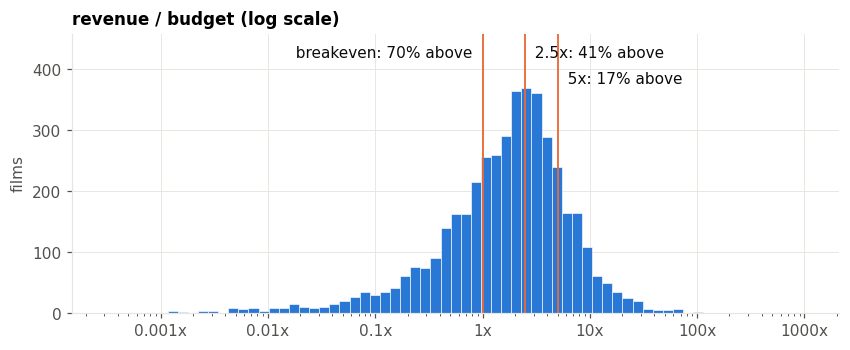

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.hist(d["roi"], bins=np.logspace(-3.5, np.log10(200), 60), color=BLUE, edgecolor="white", linewidth=0.4)
ax.set_xscale("log")
ax.set_xlim(10 ** -3.5, 250)  # nothing past 180x
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
top = ax.get_ylim()[1]
for x, name, align, height in [(1, "breakeven", "right", 1.08), (2.5, "2.5x", "left", 1.08), (5, "5x", "left", 0.97)]:
    ax.axvline(x, color=ORANGE, linewidth=1.2)
    label = f"{name}: {(d.roi > x).mean():.0%} above"
    ax.text(x, top * height, f" {label} ", color=INK, ha=align, va="center", zorder=3,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))  # white behind so the next line doesn't cut through
ax.set_ylim(0, top * 1.18)
ax.set_title("revenue / budget (log scale)")
ax.set_ylabel("films")
save(fig, "02_roi_dist")

print(f"median roi {d.roi.median():.2f}x, mean roi {d.roi.mean():.1f}x (the mean is pulled way up by a few huge hits)")
print(d.nlargest(5, "roi")[["title", "year", "budget", "revenue", "roi"]].to_string(index=False))

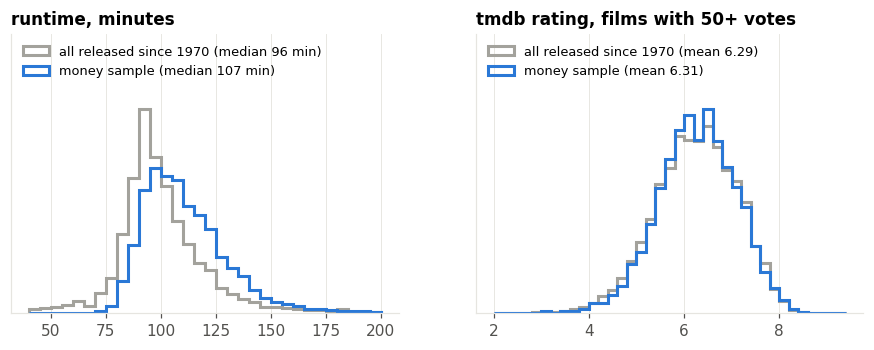

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
samples = [(allm, GRAY, "all released since 1970"), (d, BLUE, "money sample")]

for data, color, name in samples:
    axes[0].hist(data["runtime"], bins=np.arange(40, 205, 5), density=True,
                 histtype="step", linewidth=2, color=color, label=f"{name} (median {data.runtime.median():.0f} min)")
    axes[1].hist(data["rating"].dropna(), bins=np.arange(2, 9.6, 0.2), density=True,
                 histtype="step", linewidth=2, color=color, label=f"{name} (mean {data.rating.mean():.2f})")

axes[0].set_title("runtime, minutes")
axes[1].set_title(f"tmdb rating, films with {MIN_VOTES}+ votes")
for ax in axes:
    ax.set_yticks([])
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
    ax.legend(loc="upper left", fontsize=8.5)
save(fig, "03_runtime_rating_dist")

**2. genre, year, country, month.**

,films,profitable,over_2_5x,median_roi,median_budget,rating
genre,,,,,,
Family,490,0.78,0.47,2.38,61278066.00,6.23
Animation,265,0.76,0.50,2.52,74416469.89,6.52
Adventure,864,0.75,0.45,2.21,69876113.55,6.24
Fantasy,466,0.75,0.42,2.11,62124749.28,6.20
Horror,446,0.74,0.47,2.35,20715862.31,5.85
Science Fiction,563,0.72,0.39,1.94,54485749.85,6.16
Comedy,1550,0.72,0.43,2.05,31025569.90,6.15
Action,1268,0.72,0.39,1.96,51065055.00,6.14
Crime,739,0.69,0.37,1.82,31566275.62,6.41


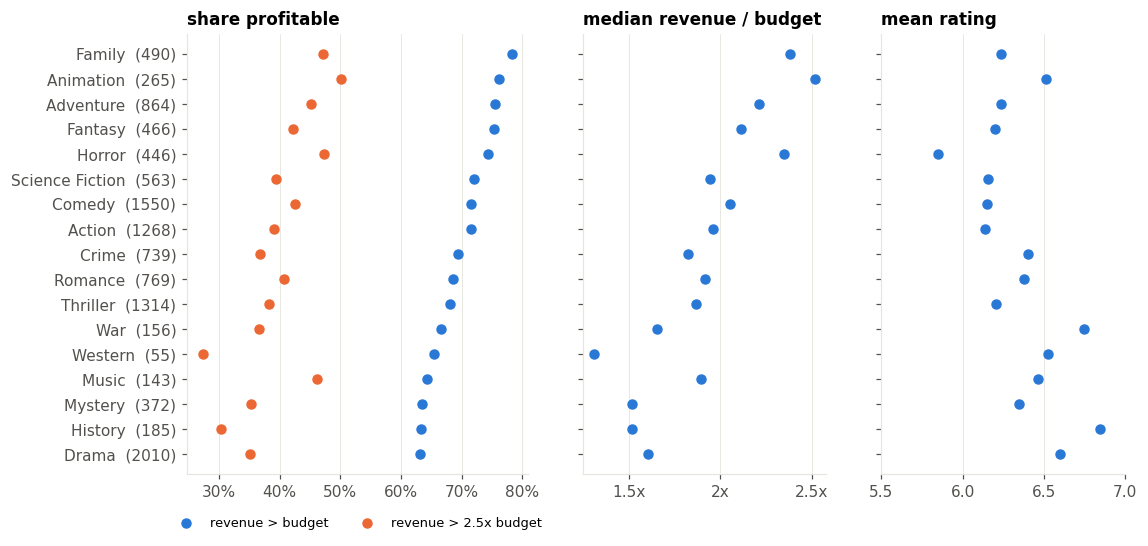

In [7]:
by_genre = (
    d.assign(genre=d["genres"].str.split("|")).explode("genre")
    .groupby("genre")
    .agg(films=("id", "size"), profitable=("profitable", "mean"), over_2_5x=("hit_2_5x", "mean"),
         median_roi=("roi", "median"), median_budget=("budget_real", "median"), rating=("rating", "mean"))
)
by_genre = by_genre[by_genre["films"] >= 30].sort_values("profitable")
labels = [f"{g}  ({n})" for g, n in zip(by_genre.index, by_genre.films)]

fig, axes = plt.subplots(1, 3, figsize=(11, 5.2), sharey=True, gridspec_kw={"width_ratios": [1.4, 1, 1]})
dots(axes[0], labels, [(by_genre.profitable, BLUE, "revenue > budget"),
                       (by_genre.over_2_5x, ORANGE, "revenue > 2.5x budget")], "share profitable")
axes[0].xaxis.set_major_formatter(PCT)
legend_below(axes[0])
dots(axes[1], labels, [(by_genre.median_roi, BLUE, "")], "median revenue / budget")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
dots(axes[2], labels, [(by_genre.rating, BLUE, "")], "mean rating")
axes[2].set_xlim(RATING_RANGE)
save(fig, "04_genre")

by_genre.sort_values("profitable", ascending=False).round(2)

,films,profitable,over_2_5x,median_budget,rating
period,,,,,
1970,72,0.89,0.71,22781903.37,6.98
1975,85,0.92,0.75,24265928.78,6.89
1980,189,0.75,0.51,29744514.11,6.66
1985,285,0.66,0.44,28041444.10,6.47
1990,337,0.63,0.41,35633190.08,6.38
1995,503,0.65,0.35,45111727.42,6.32
2000,660,0.69,0.38,42764426.41,6.22
2005,877,0.68,0.34,31378653.72,6.20
2010,927,0.71,0.41,27242874.93,6.26


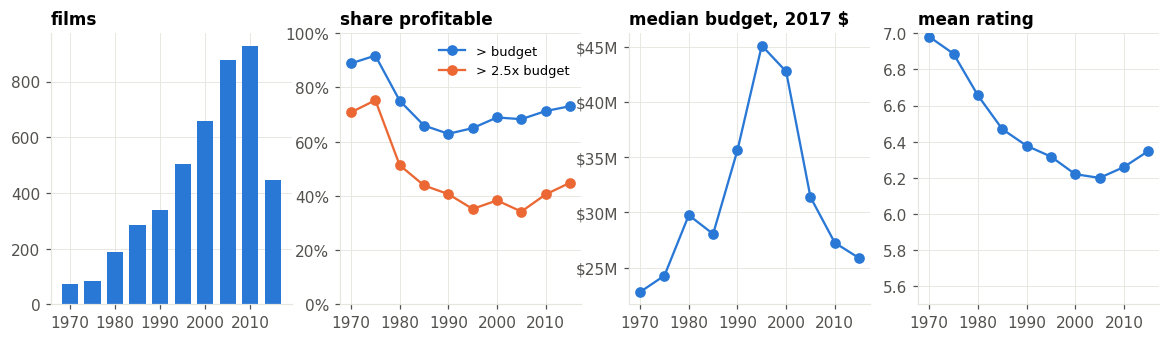

In [8]:
d["period"] = (d["year"] // 5 * 5).astype(int)
by_period = d.groupby("period").agg(
    films=("id", "size"), profitable=("profitable", "mean"), over_2_5x=("hit_2_5x", "mean"),
    median_budget=("budget_real", "median"), rating=("rating", "mean"))

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
x = by_period.index
axes[0].bar(x, by_period.films, width=3.6, color=BLUE)
axes[0].set_title("films")
axes[1].plot(x, by_period.profitable, "o-", color=BLUE, label="> budget")
axes[1].plot(x, by_period.over_2_5x, "o-", color=ORANGE, label="> 2.5x budget")
axes[1].yaxis.set_major_formatter(PCT)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8.5)
axes[1].set_title("share profitable")
axes[2].plot(x, by_period.median_budget, "o-", color=BLUE)
axes[2].yaxis.set_major_formatter(MONEY)
axes[2].set_title("median budget, 2017 $")
axes[3].plot(x, by_period.rating, "o-", color=BLUE)
axes[3].set_ylim(RATING_RANGE)
axes[3].set_title("mean rating")
for ax in axes:
    ax.set_xticks([1970, 1980, 1990, 2000, 2010])
save(fig, "05_year")

by_period.round(2)

a film counts for every country that co-produced it


,films,profitable,over_2_5x,median_roi,median_budget,rating
country,,,,,,
United States of America,3739,0.71,0.42,2.05,37152124.24,6.27
United Kingdom,578,0.66,0.40,1.87,31378653.72,6.51
France,322,0.57,0.30,1.27,21979742.19,6.43
Germany,289,0.61,0.29,1.50,41527362.57,6.29
Canada,209,0.65,0.33,1.83,26945708.55,6.09
India,107,0.85,0.48,2.49,10621531.44,6.72
Australia,104,0.66,0.33,1.54,40726299.34,6.13
Italy,82,0.51,0.23,1.02,22298266.69,6.46
Japan,78,0.71,0.44,1.91,26080222.44,6.46


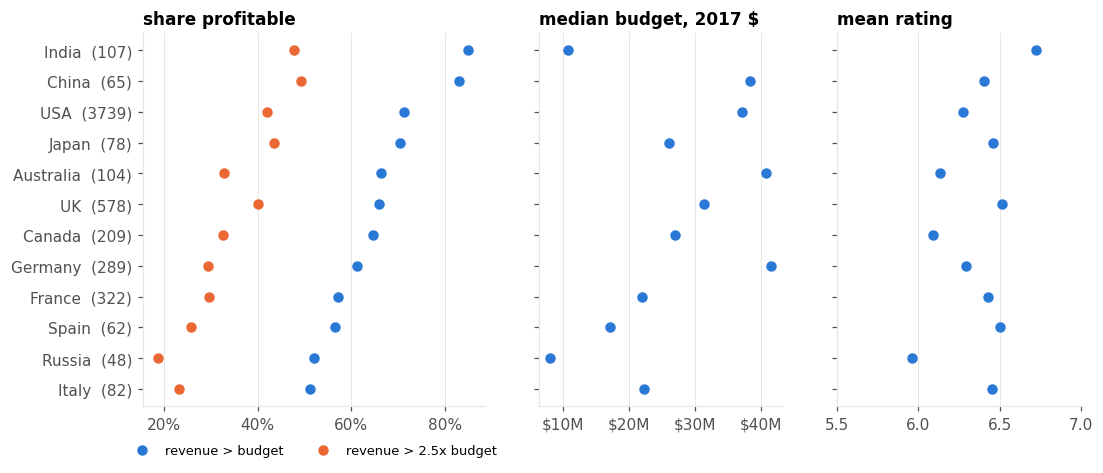

In [9]:
by_country = (
    d.assign(country=d["countries"].str.split("|")).explode("country")
    .groupby("country")
    .agg(films=("id", "size"), profitable=("profitable", "mean"), over_2_5x=("hit_2_5x", "mean"),
         median_roi=("roi", "median"), median_budget=("budget_real", "median"), rating=("rating", "mean"))
    .nlargest(12, "films")
    .sort_values("profitable")
)
short = {"United States of America": "USA", "United Kingdom": "UK"}
labels = [f"{short.get(c, c)}  ({n})" for c, n in zip(by_country.index, by_country.films)]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.4), sharey=True, gridspec_kw={"width_ratios": [1.4, 1, 1]})
dots(axes[0], labels, [(by_country.profitable, BLUE, "revenue > budget"),
                       (by_country.over_2_5x, ORANGE, "revenue > 2.5x budget")], "share profitable")
axes[0].xaxis.set_major_formatter(PCT)
legend_below(axes[0])
dots(axes[1], labels, [(by_country.median_budget, BLUE, "")], "median budget, 2017 $")
axes[1].xaxis.set_major_formatter(MONEY)
dots(axes[2], labels, [(by_country.rating, BLUE, "")], "mean rating")
axes[2].set_xlim(RATING_RANGE)
save(fig, "06_country")

print("a film counts for every country that co-produced it")
by_country.sort_values("films", ascending=False).round(2)

,films,profitable,over_2_5x,median_roi
month,,,,
1.0,255,0.67,0.38,1.74
2.0,302,0.66,0.38,1.80
3.0,335,0.70,0.39,1.90
4.0,322,0.68,0.36,1.75
5.0,341,0.75,0.46,2.29
6.0,384,0.80,0.51,2.54
7.0,358,0.79,0.47,2.43
8.0,377,0.67,0.36,1.73
9.0,494,0.56,0.28,1.27


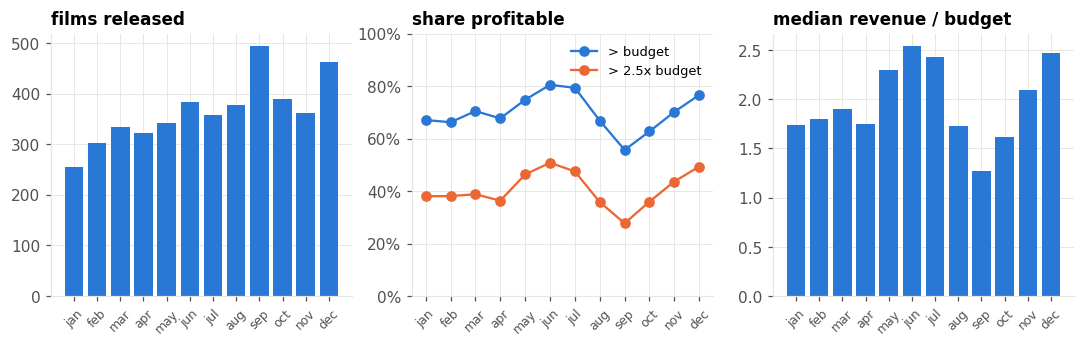

In [10]:
by_month = d.groupby("month").agg(films=("id", "size"), profitable=("profitable", "mean"),
                                  over_2_5x=("hit_2_5x", "mean"), median_roi=("roi", "median"))
months = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.1))
axes[0].bar(months, by_month.films, color=BLUE)
axes[0].set_title("films released")
axes[1].plot(months, by_month.profitable, "o-", color=BLUE, label="> budget")
axes[1].plot(months, by_month.over_2_5x, "o-", color=ORANGE, label="> 2.5x budget")
axes[1].yaxis.set_major_formatter(PCT)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8.5)
axes[1].set_title("share profitable")
axes[2].bar(months, by_month.median_roi, color=BLUE)
axes[2].set_title("median revenue / budget")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8, rotation=45)
save(fig, "07_month")

by_month.round(2)

**3. budget vs revenue and ratings.**

budget vs revenue: pearson on logs 0.61, spearman 0.64
budget vs roi:     spearman 0.05
budget vs rating:  spearman -0.08
rating vs revenue: spearman 0.18
rating vs roi:     spearman 0.29


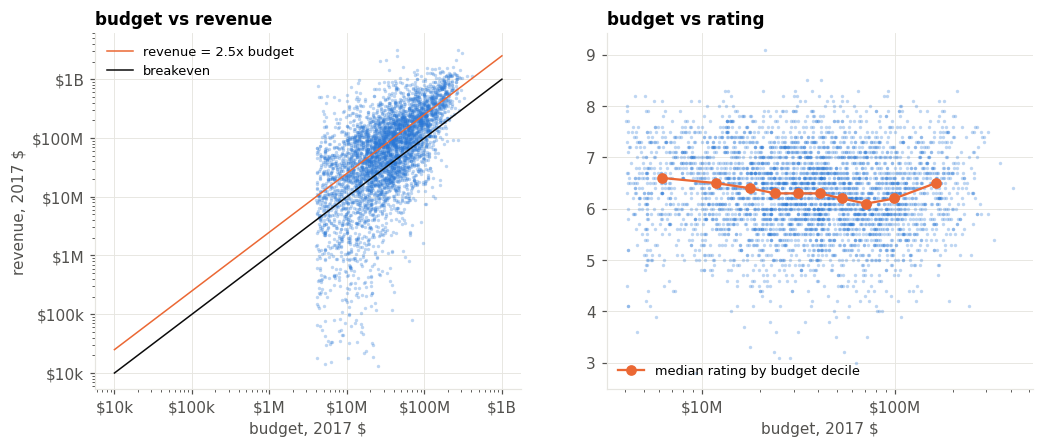

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.scatter(d.budget_real, d.revenue_real, s=5, alpha=0.3, color=BLUE, linewidths=0)
line = np.array([1e4, 1e9])
ax.plot(line, 2.5 * line, color=ORANGE, linewidth=1, label="revenue = 2.5x budget")
ax.plot(line, line, color=INK, linewidth=1, label="breakeven")
ax.legend(loc="upper left", fontsize=8.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(MONEY)
ax.yaxis.set_major_formatter(MONEY)
ax.set_xlabel("budget, 2017 $")
ax.set_ylabel("revenue, 2017 $")
ax.set_title("budget vs revenue")

rated = d.dropna(subset=["rating"])
ax = axes[1]
ax.scatter(rated.budget_real, rated.rating, s=5, alpha=0.3, color=BLUE, linewidths=0)
binned = rated.groupby(pd.qcut(rated.budget_real, 10), observed=True).agg(b=("budget_real", "median"), r=("rating", "median"))
ax.plot(binned.b, binned.r, "o-", color=ORANGE, label="median rating by budget decile")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(MONEY)
ax.set_xlabel("budget, 2017 $")
ax.set_title("budget vs rating")
ax.legend(loc="lower left", fontsize=8.5)
save(fig, "08_budget_scatter")

log_b, log_r = np.log10(d.budget_real), np.log10(d.revenue_real)
print(f"budget vs revenue: pearson on logs {np.corrcoef(log_b, log_r)[0, 1]:.2f}, spearman {d.budget_real.corr(d.revenue_real, method='spearman'):.2f}")
print(f"budget vs roi:     spearman {d.budget_real.corr(d.roi, method='spearman'):.2f}")
print(f"budget vs rating:  spearman {rated.budget_real.corr(rated.rating, method='spearman'):.2f}")
print(f"rating vs revenue: spearman {rated.rating.corr(rated.revenue_real, method='spearman'):.2f}")
print(f"rating vs roi:     spearman {rated.rating.corr(rated.roi, method='spearman'):.2f}")

,films,profitable,over_2_5x,over_5x,median_roi,median_revenue,rating
budget_tier,,,,,,,
$4-10M,622,0.63,0.40,0.25,1.77,1.095208e+07,6.47
$10-20M,816,0.65,0.42,0.24,1.87,2.677169e+07,6.39
$20-50M,1471,0.68,0.40,0.15,1.88,5.798955e+07,6.29
$50-100M,896,0.72,0.37,0.12,1.87,1.287808e+08,6.19
$100-200M,502,0.82,0.45,0.11,2.30,3.082950e+08,6.32
$200M+,74,0.96,0.66,0.22,3.16,7.783634e+08,6.50


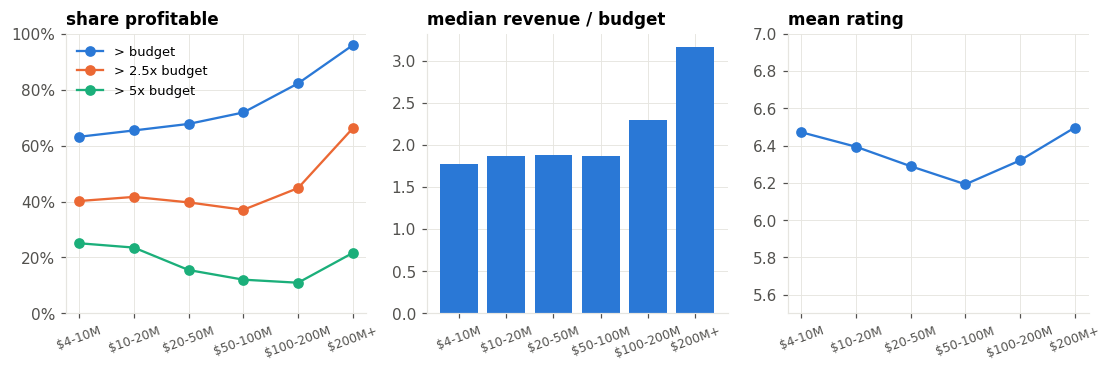

In [12]:
tiers = [0, 10e6, 20e6, 50e6, 100e6, 200e6, np.inf]
tier_names = ["$4-10M", "$10-20M", "$20-50M", "$50-100M", "$100-200M", "$200M+"]
d["budget_tier"] = pd.cut(d["budget_real"], tiers, labels=tier_names)
by_tier = d.groupby("budget_tier", observed=True).agg(
    films=("id", "size"), profitable=("profitable", "mean"), over_2_5x=("hit_2_5x", "mean"),
    over_5x=("roi", lambda r: (r > 5).mean()),
    median_roi=("roi", "median"), median_revenue=("revenue_real", "median"), rating=("rating", "mean"))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].plot(tier_names, by_tier.profitable, "o-", color=BLUE, label="> budget")
axes[0].plot(tier_names, by_tier.over_2_5x, "o-", color=ORANGE, label="> 2.5x budget")
axes[0].plot(tier_names, by_tier.over_5x, "o-", color=AQUA, label="> 5x budget")
axes[0].yaxis.set_major_formatter(PCT)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8.5)
axes[0].set_title("share profitable")
axes[1].bar(tier_names, by_tier.median_roi, color=BLUE)
axes[1].set_title("median revenue / budget")
axes[2].plot(tier_names, by_tier.rating, "o-", color=BLUE)
axes[2].set_ylim(RATING_RANGE)
axes[2].set_title("mean rating")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8, rotation=20)
save(fig, "09_budget_tiers")

by_tier.round(2)

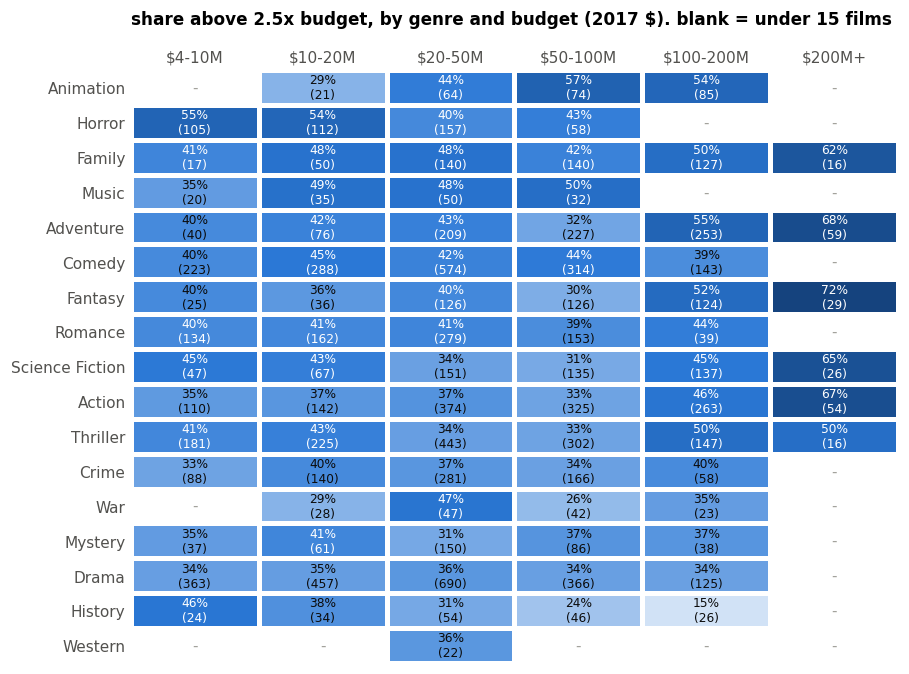

In [13]:
MIN_FILMS = 15  # cells with fewer films than this stay blank

g = d.assign(genre=d["genres"].str.split("|")).explode("genre")
g = g[g["genre"].isin(by_genre.index)]
share = g.pivot_table(index="genre", columns="budget_tier", values="hit_2_5x", aggfunc="mean", observed=True)
films = g.pivot_table(index="genre", columns="budget_tier", values="id", aggfunc="size", observed=True)
share = share.where(films >= MIN_FILMS)

order = g.groupby("genre")["hit_2_5x"].mean().sort_values(ascending=False).index
share, films = share.loc[order], films.loc[order]

blues = LinearSegmentedColormap.from_list("blues", ["#eef4fc", BLUE, "#0f3566"])
fig, ax = plt.subplots(figsize=(9, 7))
ax.pcolormesh(np.ma.masked_invalid(share.values), cmap=blues, vmin=0.1, vmax=0.8,
              edgecolors="white", linewidth=2)
for i, genre in enumerate(share.index):
    for j, tier in enumerate(share.columns):
        value, n = share.loc[genre, tier], films.loc[genre, tier]
        if pd.isna(value):
            ax.text(j + 0.5, i + 0.5, "-", ha="center", va="center", color=GRAY)
        else:
            ax.text(j + 0.5, i + 0.5, f"{value:.0%}\n({n:.0f})", ha="center", va="center", fontsize=8,
                    color="white" if value > 0.4 else INK)

ax.set_xticks(np.arange(len(share.columns)) + 0.5, share.columns)
ax.set_yticks(np.arange(len(share.index)) + 0.5, share.index)
ax.invert_yaxis()
ax.xaxis.tick_top()
ax.tick_params(length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f"share above 2.5x budget, by genre and budget (2017 $). blank = under {MIN_FILMS} films", pad=30)
save(fig, "09b_genre_by_budget")

**4. strategy cuts.**

films  profitable  over_2_5x  median_roi  median_budget  \
cut         group                                                            
sequel      no      3855        0.67       0.37        1.76   3.012351e+07   
            yes      526        0.91       0.67        3.29   6.001656e+07   
adaptation  no      3706        0.69       0.40        1.90   3.109120e+07   
            yes      675        0.73       0.44        2.20   4.085204e+07   
superhero   no      4311        0.69       0.40        1.94   3.161395e+07   
            yes       70        0.91       0.63        3.31   1.477860e+08   
independent no      4238        0.71       0.42        2.02   3.374158e+07   
            yes      143        0.36       0.14        0.54   1.093935e+07   
3d          no      4273        0.69       0.40        1.92   3.156628e+07   
            yes      108        0.92       0.61        2.88   1.138279e+08   

                   rating  
cut         group          
sequel      no       6.36  
            yes      6.01  
adaptation  no       6.29  
            yes      6.45  
superhero   no       6.31  
            yes      6.31  
independent no       6.31  
            yes      6.52  
3d          no       6.32  
            yes      6.20

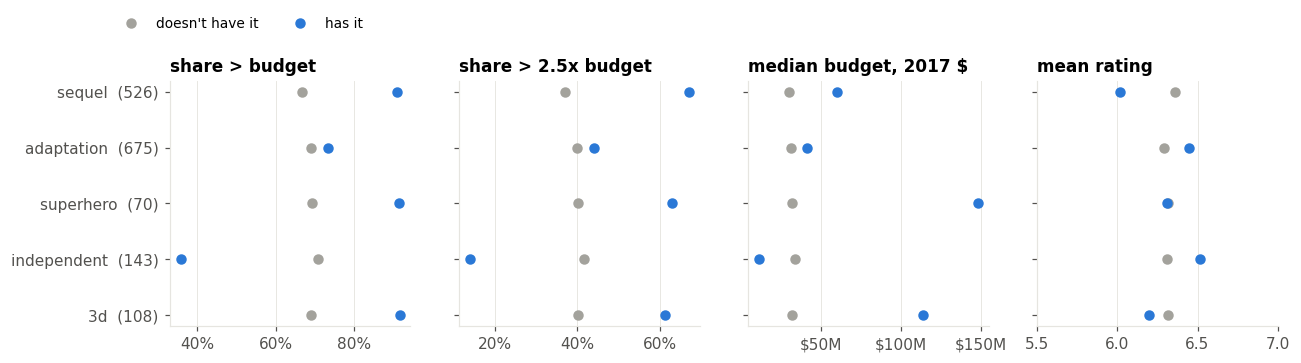

In [14]:
cuts = {"sequel": "is_sequel", "adaptation": "is_adaptation",
        "superhero": "is_superhero", "independent": "is_independent", "3d": "is_3d"}
rows = []
for name, col in cuts.items():
    for value, group in d.groupby(col):
        rows.append({"cut": name, "group": "yes" if value else "no", "films": len(group),
                     "profitable": group.profitable.mean(), "over_2_5x": group.hit_2_5x.mean(),
                     "median_roi": group.roi.median(), "median_budget": group.budget_real.median(),
                     "rating": group.rating.mean()})
by_cut = pd.DataFrame(rows).set_index(["cut", "group"])

names = list(cuts)
yes = by_cut.xs("yes", level="group").loc[names]
no = by_cut.xs("no", level="group").loc[names]
labels = [f"{n}  ({yes.films[n]})" for n in names]
panels = [("profitable", "share > budget", PCT), ("over_2_5x", "share > 2.5x budget", PCT),
          ("median_budget", "median budget, 2017 $", MONEY), ("rating", "mean rating", None)]

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9), sharey=True)
for ax, (col, title, fmt) in zip(axes, panels):
    dots(ax, labels, [(no[col], GRAY, "doesn't have it"), (yes[col], BLUE, "has it")], title)
    if fmt:
        ax.xaxis.set_major_formatter(fmt)
axes[3].set_xlim(RATING_RANGE)
axes[0].invert_yaxis()
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower left", bbox_to_anchor=(0.08, 1.0), ncol=2, fontsize=9)
save(fig, "10_strategy_cuts")

by_cut.round(2)